Dataset Overview

This dataset contains detailed information about telecom customers in the United States, including their demographic details, subscription plans, and churn status. The data has been collected to help identify the key factors contributing to customer churn, which occurs when customers cancel their services.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_excel('Data/Telco_customer_churn.xlsx')

In [3]:
dataset.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df = dataset.copy()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df.shape

(7043, 33)

In [7]:
df.head(2)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved


In [8]:
df.columns = [x.lower() for x in df.columns]

In [9]:
df.columns

Index(['customerid', 'count', 'country', 'state', 'city', 'zip code',
       'lat long', 'latitude', 'longitude', 'gender', 'senior citizen',
       'partner', 'dependents', 'tenure months', 'phone service',
       'multiple lines', 'internet service', 'online security',
       'online backup', 'device protection', 'tech support', 'streaming tv',
       'streaming movies', 'contract', 'paperless billing', 'payment method',
       'monthly charges', 'total charges', 'churn label', 'churn value',
       'churn score', 'cltv', 'churn reason'],
      dtype='object')

In [10]:
# Duplicate checking ---
df.duplicated().sum()

np.int64(0)

In [11]:
df.isnull().sum()

customerid              0
count                   0
country                 0
state                   0
city                    0
zip code                0
lat long                0
latitude                0
longitude               0
gender                  0
senior citizen          0
partner                 0
dependents              0
tenure months           0
phone service           0
multiple lines          0
internet service        0
online security         0
online backup           0
device protection       0
tech support            0
streaming tv            0
streaming movies        0
contract                0
paperless billing       0
payment method          0
monthly charges         0
total charges           0
churn label             0
churn value             0
churn score             0
cltv                    0
churn reason         5174
dtype: int64

##### Target feature

In [12]:
df['churn label'].value_counts(normalize=True)*100

churn label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

#### Droping features --

In [13]:
df['count'].value_counts() # count isn't important

count
1    7043
Name: count, dtype: int64

In [14]:
df.columns

Index(['customerid', 'count', 'country', 'state', 'city', 'zip code',
       'lat long', 'latitude', 'longitude', 'gender', 'senior citizen',
       'partner', 'dependents', 'tenure months', 'phone service',
       'multiple lines', 'internet service', 'online security',
       'online backup', 'device protection', 'tech support', 'streaming tv',
       'streaming movies', 'contract', 'paperless billing', 'payment method',
       'monthly charges', 'total charges', 'churn label', 'churn value',
       'churn score', 'cltv', 'churn reason'],
      dtype='object')

In [15]:
df.drop(columns=['customerid', 'count', 'lat long'], inplace=True, axis=1)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            7043 non-null   object 
 1   state              7043 non-null   object 
 2   city               7043 non-null   object 
 3   zip code           7043 non-null   int64  
 4   latitude           7043 non-null   float64
 5   longitude          7043 non-null   float64
 6   gender             7043 non-null   object 
 7   senior citizen     7043 non-null   object 
 8   partner            7043 non-null   object 
 9   dependents         7043 non-null   object 
 10  tenure months      7043 non-null   int64  
 11  phone service      7043 non-null   object 
 12  multiple lines     7043 non-null   object 
 13  internet service   7043 non-null   object 
 14  online security    7043 non-null   object 
 15  online backup      7043 non-null   object 
 16  device protection  7043 

### Categorical Feature ---

In [17]:
categorical_feature = [x for x in df.columns if df[x].dtype == 'object']

In [18]:
categorical_feature

['country',
 'state',
 'city',
 'gender',
 'senior citizen',
 'partner',
 'dependents',
 'phone service',
 'multiple lines',
 'internet service',
 'online security',
 'online backup',
 'device protection',
 'tech support',
 'streaming tv',
 'streaming movies',
 'contract',
 'paperless billing',
 'payment method',
 'total charges',
 'churn label',
 'churn reason']

In [19]:
for feature in categorical_feature:
    print(f"It is {feature} feature")
    print(df[feature].value_counts())
    print("+++++++++++++++++++++++++++++++")
        

It is country feature
country
United States    7043
Name: count, dtype: int64
+++++++++++++++++++++++++++++++
It is state feature
state
California    7043
Name: count, dtype: int64
+++++++++++++++++++++++++++++++
It is city feature
city
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
                ... 
Chester            4
Big Bar            4
Washington         4
Stonyford          4
Stirling City      4
Name: count, Length: 1129, dtype: int64
+++++++++++++++++++++++++++++++
It is gender feature
gender
Male      3555
Female    3488
Name: count, dtype: int64
+++++++++++++++++++++++++++++++
It is senior citizen feature
senior citizen
No     5901
Yes    1142
Name: count, dtype: int64
+++++++++++++++++++++++++++++++
It is partner feature
partner
No     3641
Yes    3402
Name: count, dtype: int64
+++++++++++++++++++++++++++++++
It is dependents feature
dependents
No     5416
Yes    1627
Name: count, dtype: int64
++++++++++++++++++++

### Neumerical feature ---

In [20]:
numerical_feature = [x for x in df.columns if x not in categorical_feature]

In [21]:
numerical_feature

['zip code',
 'latitude',
 'longitude',
 'tenure months',
 'monthly charges',
 'churn value',
 'churn score',
 'cltv']

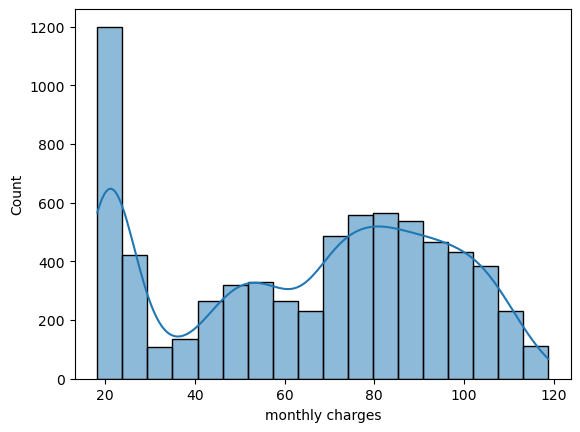

In [22]:
sns.histplot(x='monthly charges', data=df, kde=True)
plt.xlabel('monthly charges')
plt.show()

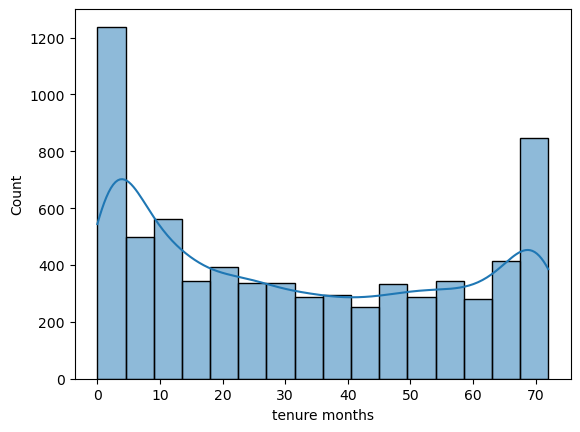

In [23]:
sns.histplot(x='tenure months', data=df, kde=True)
plt.xlabel('tenure months')
plt.show()

<Axes: >

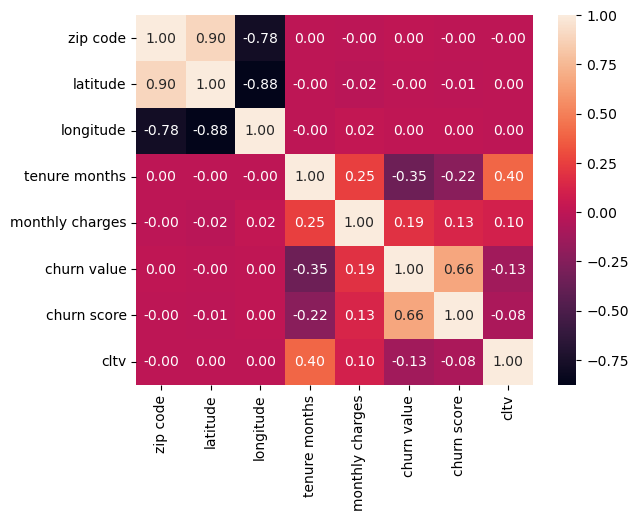

In [27]:
sns.heatmap(df[numerical_feature].corr(), annot=True, fmt='.2f')

# Conclusion

1. Dataset have no Null, duplicated value.
2. The target feature "churn label" are two type, that distributed in 74% No & 26% Yes.
3. Most of Categorical feature are Two and Three types. But "churn reason" is having descrivetive data.
4. In numerical features, most of are Location centric feature.
5. Count, Country, State having only one unique value and CustomerId also not usefull for coustomer churn prediction.